In [120]:
# necessary imports

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm

sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.dpi": 300,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

def regplot_clean(
    data, x, y, xlabel, ylabel, title, subtitle=None,
    title_size=22, subtitle_size=12
):
    g = sns.lmplot(
        data=data,
        x=x, y=y,
        height=5.0, aspect=1.25,
        scatter_kws={"alpha": 0.6, "s": 40},
        line_kws={"color": "black", "linewidth": 2},
        ci=95
    )

    fig = g.fig
    ax = g.ax

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linewidth=0.5, alpha=0.35)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1)

    fig.suptitle(
        title,
        x=0.08, y=1.03, ha="left",
        fontsize=title_size
    )
    if subtitle:
        ax.set_title(
            subtitle,
            loc="left",
            fontsize=subtitle_size,
            fontfamily="Source Sans Pro",
            pad=6
        )

    fig.tight_layout()
    fig.subplots_adjust(top=0.88)
    return fig

### Initial Data Cleaning and Preprocessing

In [121]:
# read in csv

merged = pd.read_csv("../data/merged/merged_arrests_acs_2023.csv")
merged.head()

,ZCTA,total_arrests,felonies,misdemeanors,violations,AMERICAN INDIAN/ALASKAN NATIVE,ASIAN / PACIFIC ISLANDER,BLACK,BLACK HISPANIC,UNKNOWN,...,pct_native,pct_asian,pct_hispanic,arrest_rate_per_1000,HISPANIC_ARRESTS,black_arrest_rate_per_1000,white_arrest_rate_per_1000,asian_pacific_islander_arrest_rate_per_1000,american_indian/alaskan_native_arrest_rate_per_1000,hispanic_arrest_rate_per_1000
0,83,172,75,97,0,4,3,65,20,6,...,NaN,NaN,NaN,NaN,63,NaN,NaN,NaN,NaN,NaN
1,10001,4041,1660,2291,8,14,116,1798,371,106,...,0.000000,0.179786,0.190756,138.966264,1515,615.121451,34.596723,22.188217,NaN,273.120606
2,10002,2107,947,1137,8,1,166,924,209,24,...,0.000914,0.365441,0.246911,27.901002,780,140.106141,10.655408,6.015147,14.492754,41.832028
3,10003,1742,856,877,8,4,60,822,156,32,...,0.001263,0.178913,0.098189,32.364143,559,348.452734,7.685615,6.230530,58.823529,105.771050
4,10004,61,17,44,0,0,5,31,2,2,...,0.000000,0.238194,0.048774,15.741935,13,116.104869,4.187605,5.417118,NaN,68.783069


In [122]:
# general info and summary stats

print(merged.info())
print(merged.describe(include="all").transpose().head(20))

# count missing by column

missing = merged.isna().sum().sort_values(ascending=False)
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 32 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   ZCTA                                                 190 non-null    int64  
 1   total_arrests                                        190 non-null    int64  
 2   felonies                                             190 non-null    int64  
 3   misdemeanors                                         190 non-null    int64  
 4   violations                                           190 non-null    int64  
 5   AMERICAN INDIAN/ALASKAN NATIVE                       190 non-null    int64  
 6   ASIAN / PACIFIC ISLANDER                             190 non-null    int64  
 7   BLACK                                                190 non-null    int64  
 8   BLACK HISPANIC                                       190 non-null    i

american_indian/alaskan_native_arrest_rate_per_1000    50
black_arrest_rate_per_1000                             11
hispanic_arrest_rate_per_1000                           9
asian_pacific_islander_arrest_rate_per_1000             9
white_arrest_rate_per_1000                              9
pct_hispanic                                            9
pct_asian                                               9
pct_native                                              9
pct_black                                               9
pct_white                                               9
native_count                                            4
arrest_rate_per_1000                                    4
below_poverty                                           4
median_income                                           4
hispanic_count                                          4
asian_count                                             4
black_count                                             4
white_count   

In [123]:
# drop rows where total_pop is missing or 0

df = merged.dropna(subset=["total_pop"]).copy()
df = df[df["total_pop"] > 0]

In [124]:
# ensure cols to numeric 

numeric_cols = [
    "total_arrests", "felonies", "misdemeanors", "violations",
    "total_pop", "white_count", "black_count", "native_count",
    "asian_count", "hispanic_count", "median_income", "below_poverty",
    "pct_white", "pct_black", "pct_native", "pct_asian", "pct_hispanic",
    "arrest_rate_per_1000"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [125]:
# drop insane values

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["arrest_rate_per_1000"])

In [126]:
# remove extreme outliers

upper_limit = df["arrest_rate_per_1000"].mean() + 3 * df["arrest_rate_per_1000"].std()
df = df[df["arrest_rate_per_1000"] < upper_limit]

In [127]:
# check key cols
 
key_cols = ["median_income", "pct_black", "pct_hispanic", "pct_asian", "pct_white"]
print(df[key_cols].isna().sum())

print(f"Final ZIPs retained: {df.shape[0]}")
df.describe().T.loc[["total_arrests", "total_pop", "arrest_rate_per_1000"]]

median_income    0
pct_black        0
pct_hispanic     0
pct_asian        0
pct_white        0
dtype: int64
Final ZIPs retained: 178


,count,mean,std,min,25%,50%,75%,max
total_arrests,178.0,1098.095506,951.950627,1.000000,329.250000,831.000000,1684.750000,5360.000000
total_pop,178.0,47699.747191,26151.578964,2195.000000,28003.500000,42456.500000,68430.750000,107060.000000
arrest_rate_per_1000,178.0,22.514149,17.818314,0.242542,9.727657,17.510165,31.969244,90.590112


In [128]:
df = df[df["total_pop"] > 20000].copy()
print(f"ZIPs kept: {df.shape[0]}")

ZIPs kept: 151


## Exploratory and Analytical Section

### 1. Descriptive Grounding (What does NYC look like in this data?)

#### 1.1 City Wide Aggregrates

In [129]:
# citywide totals from merged df

tot_arrests = df["total_arrests"].sum()
tot_pop = df["total_pop"].sum()
overall_rate = tot_arrests / tot_pop * 1000

tot_black_arrests = df.get("BLACK", pd.Series(0)).sum()
tot_white_arrests = df.get("WHITE", pd.Series(0)).sum()
tot_hisp_arrests = (df.get("WHITE HISPANIC", 0) + df.get("BLACK HISPANIC", 0)).sum()

tot_black_pop = df["black_count"].sum()
tot_white_pop = df["white_count"].sum()
tot_hisp_pop = df["hispanic_count"].sum()

print("Total arrests (2023, NYPD, in-scope ZIPs):", int(tot_arrests))
print("Total population (ACS 2023 5-year, these ZIPs):", int(tot_pop))
print("Overall arrest rate per 1,000:", overall_rate)

print("Black arrests:", int(tot_black_arrests), " | Black pop:", int(tot_black_pop))
print("White arrests:", int(tot_white_arrests), " | White pop:", int(tot_white_pop))
print("Hispanic arrests:", int(tot_hisp_arrests), " | Hispanic pop:", int(tot_hisp_pop))

Total arrests (2023, NYPD, in-scope ZIPs): 189260
Total population (ACS 2023 5-year, these ZIPs): 8179220
Overall arrest rate per 1,000: 23.13912573570585
Black arrests: 87590  | Black pop: 1721635
White arrests: 18601  | White pop: 2520787
Hispanic arrests: 69365  | Hispanic pop: 2356066


Note: These numbers can ground the foundation for the analysis.

#### 1.2 Distribution of arrest intensity

In [130]:
df["arrest_rate_per_1000"].describe()

count    151.000000
mean      23.266567
std       16.861986
min        0.614019
25%       10.517272
50%       18.608023
75%       32.908930
max       90.590112
Name: arrest_rate_per_1000, dtype: float64

#### 1.3 Top and bottom zip codes according to arrest_rate_per_1000

In [131]:
top10 = df.sort_values("arrest_rate_per_1000", ascending=False)[
    ["ZCTA", "total_arrests", "total_pop", "arrest_rate_per_1000",
     "pct_black", "pct_hispanic", "pct_white", "pct_asian", "median_income"]
].head(10)

bottom10 = df.sort_values("arrest_rate_per_1000", ascending=True)[
    ["ZCTA", "total_arrests", "total_pop", "arrest_rate_per_1000",
     "pct_black", "pct_hispanic", "pct_white", "pct_asian", "median_income"]
].head(10)

print("Top 10 zip codes according to arrest rate per 1000 people:")
display(top10.head())

print("Bottom 10 zip codes according to arrest rate per 1000 people:")
display(bottom10.head())

Top 10 zip codes according to arrest rate per 1000 people:


,ZCTA,total_arrests,total_pop,arrest_rate_per_1000,pct_black,pct_hispanic,pct_white,pct_asian,median_income
12,10013,2556,28215.0,90.590112,0.032430,0.077583,0.530569,0.305547,159474.0
33,10035,3173,39082.0,81.188271,0.352311,0.418121,0.140525,0.056190,40556.0
62,10451,3683,48975.0,75.201633,0.395569,0.508341,0.059990,0.011373,37111.0
50,10301,2824,39799.0,70.956557,0.227242,0.292319,0.368276,0.074876,84937.0
65,10454,2829,40368.0,70.080262,0.233725,0.702388,0.032972,0.003047,27500.0


Bottom 10 zip codes according to arrest rate per 1000 people:


,ZCTA,total_arrests,total_pop,arrest_rate_per_1000,pct_black,pct_hispanic,pct_white,pct_asian,median_income
90,11040,26,42344.0,0.614019,0.011761,0.111940,0.385509,0.438031,153511.0
87,11001,30,25714.0,1.166680,0.055145,0.154507,0.512561,0.242747,144755.0
45,10128,174,59000.0,2.949153,0.052898,0.125525,0.673881,0.103576,148705.0
43,10075,72,23865.0,3.016970,0.008213,0.053300,0.791913,0.095370,146556.0
145,11364,114,36417.0,3.130406,0.018618,0.151715,0.294286,0.502265,101222.0


Interpreting the top zip codes:

- Bronx and Harlem ZIPs (10451, 10454, 10035) are classically high-arrest areas, racially diverse, and lower-income.
- Staten Island’s 10301 shows moderate-income, diverse composition.
- 10013 (Tribeca/SoHo) is the only anomaly which is likely driven by daytime influx again (small resident base, major nightlife/commercial policing).
  - Why may this be?
    - Heavy commercial density (bars, protests, SoHo retail theft arrests, etc.) so its high rate likely reflects policing of public activity rather than residential crime (similar to what Ariel mentioned in her exploratory analysis)

Interpreting the bottom zip codes:
- These are wealthy, low-crime, majority-White/Asian neighborhoods, which should appear at the low end of arrest intensity and they do. Higher-income, majority-White ZIPs show the lowest arrest intensities; lower-income, racially diverse Bronx and Harlem ZIPs show the highest.


### 2. Exploratory Relationships

#### 2.1 Correlation Matrix

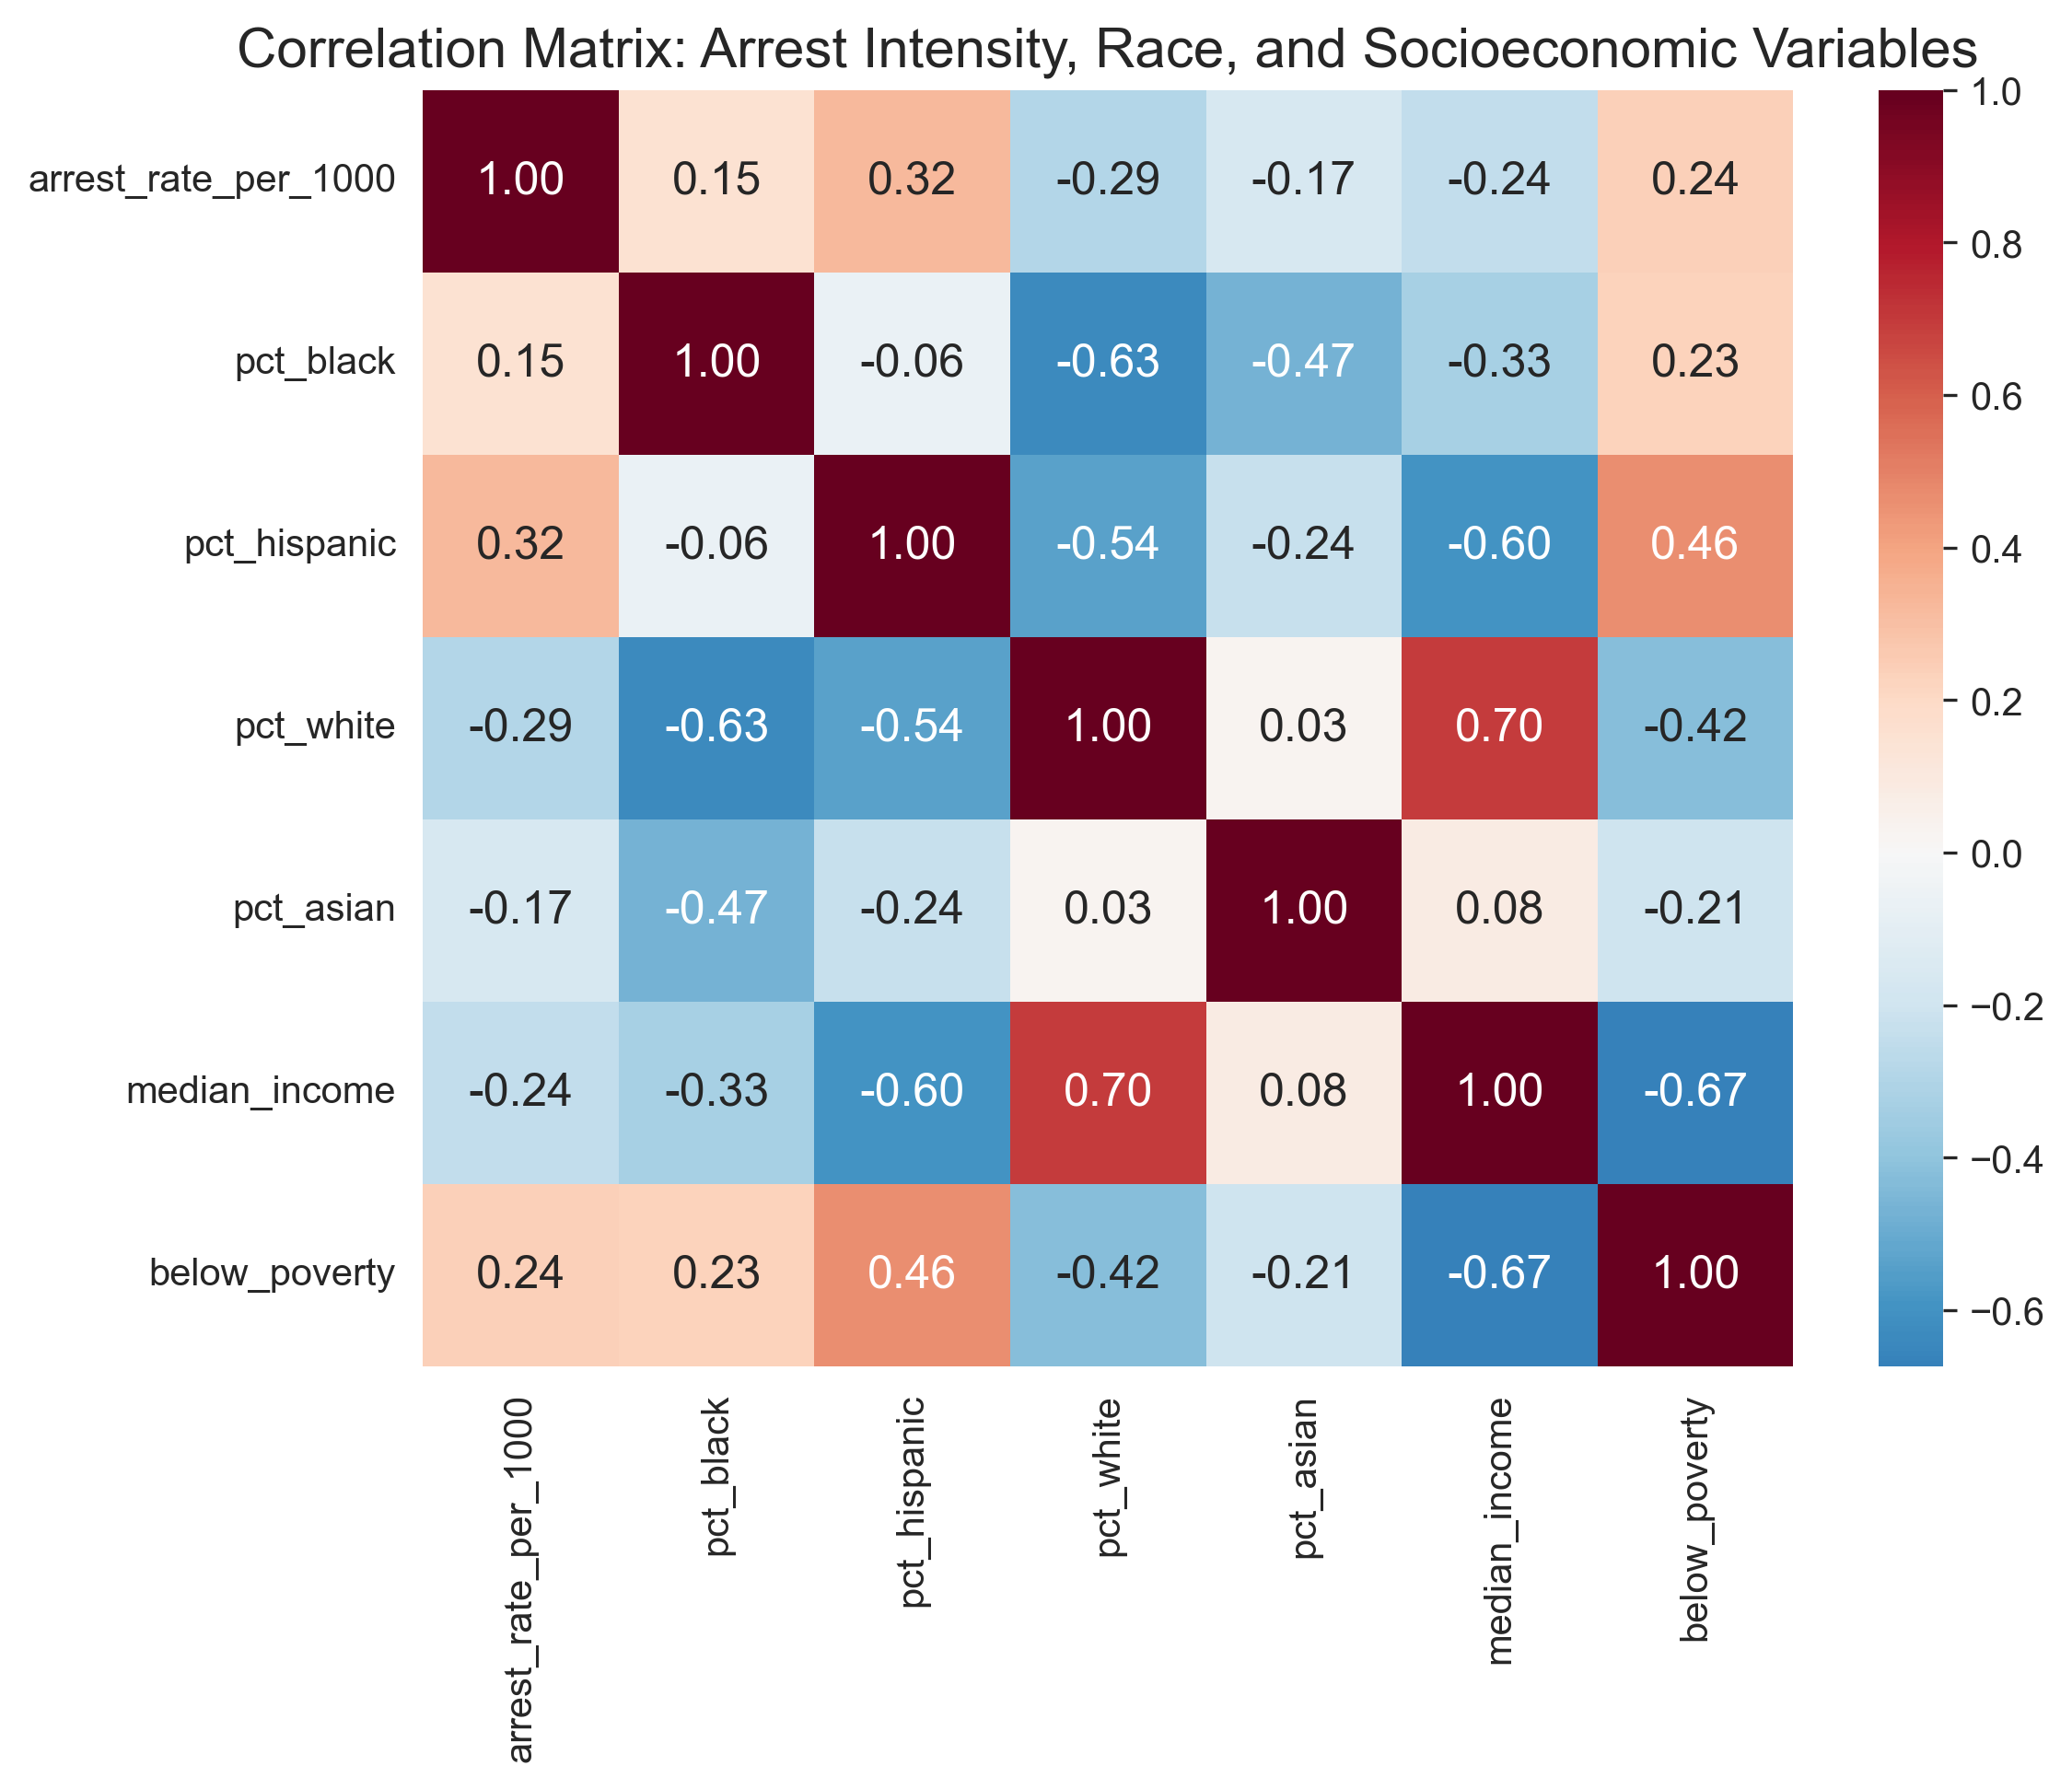

In [132]:
corr_vars = [
    "arrest_rate_per_1000",
    "pct_black", "pct_hispanic", "pct_white", "pct_asian",
    "median_income", "below_poverty"
]

corr = df[corr_vars].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Matrix: Arrest Intensity, Race, and Socioeconomic Variables")
plt.show()

Key takeaways:
- Arrest intensity and race  
  - Arrest intensity shows a moderate positive correlation with the share of Hispanic residents (r = 0.32), indicating that ZIP codes with larger Hispanic populations tend to experience higher arrest rates.  
  - The correlation with the Black population share is weaker but positive (r = 0.15), still suggesting somewhat greater exposure to arrests in predominantly Black areas.  
  - Arrest intensity is negatively correlated with the proportion of White (r = –0.29) and Asian (r = –0.17) residents, meaning these ZIP codes generally experience fewer arrests per capita.

- Arrest intensity and socioeconomic context  
  - Arrest intensity is lower in higher-income areas, reflected by a negative correlation with median income (r = –0.24).  
  - ZIP codes with higher rates of poverty show greater arrest intensity (r = +0.24), reinforcing the connection between economic disadvantage and policing exposure.

- Relationships among predictors  
  - Racial composition and class are strongly intertwined:  
    - Percent White and median income correlate positively (r = +0.70), showing that wealthier neighborhoods tend to be Whiter.  
    - Percent Hispanic correlates negatively with income (r = –0.60) and positively with poverty (r = +0.46).  
    - Percent Black also correlates negatively with income (r = –0.33) and positively with poverty (r = +0.23).  
  - These patterns highlight how race and socioeconomic inequality overlap spatially in New York City.

- Overall interpretation  
  - Higher arrest rates cluster in ZIP codes with greater Hispanic and Black populations and lower median incomes, whereas wealthier, Whiter, and Asian-majority ZIP codes experience less police contact.  
  - The consistent direction of these correlations supports a structural pattern of racialized and class-based disparities in policing intensity rather than random or individual-level differences.  
  - These results are descriptive, not causal, but they provide strong evidence that socioeconomic and racial geographies shape patterns of enforcement across the city.


#### 2.2 Pairwise Relationships

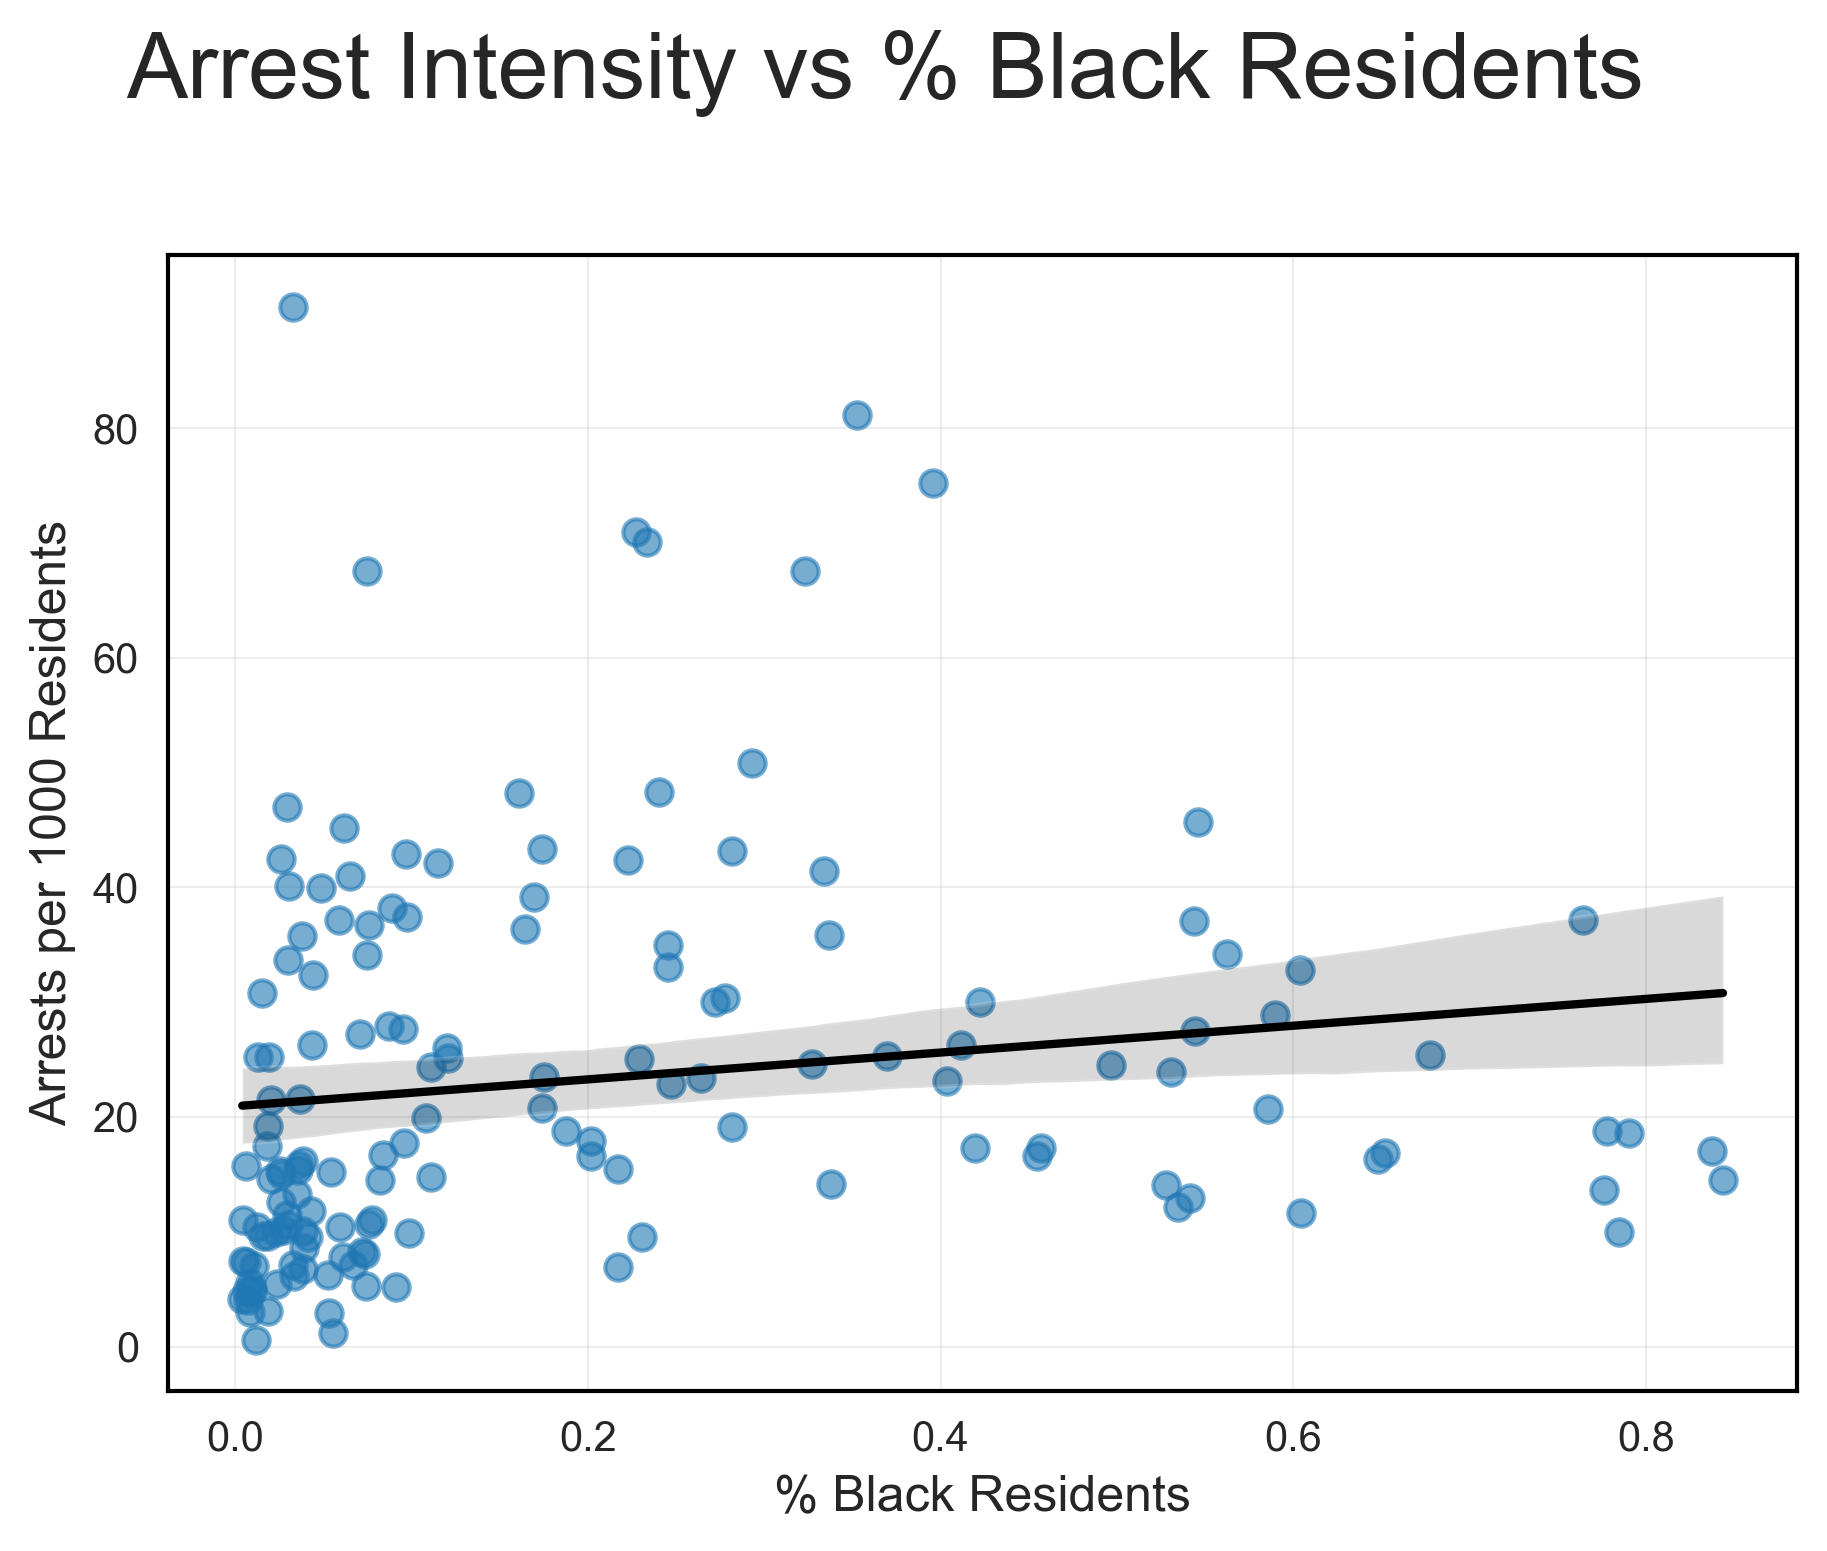

In [133]:
fig1 = regplot_clean(
    df, "pct_black", "arrest_rate_per_1000",
    "% Black Residents", "Arrests per 1000 Residents",
    "Arrest Intensity vs % Black Residents"
)
fig1.savefig("../outputs/arrest_vs_pct_black.png", dpi=300, bbox_inches="tight")

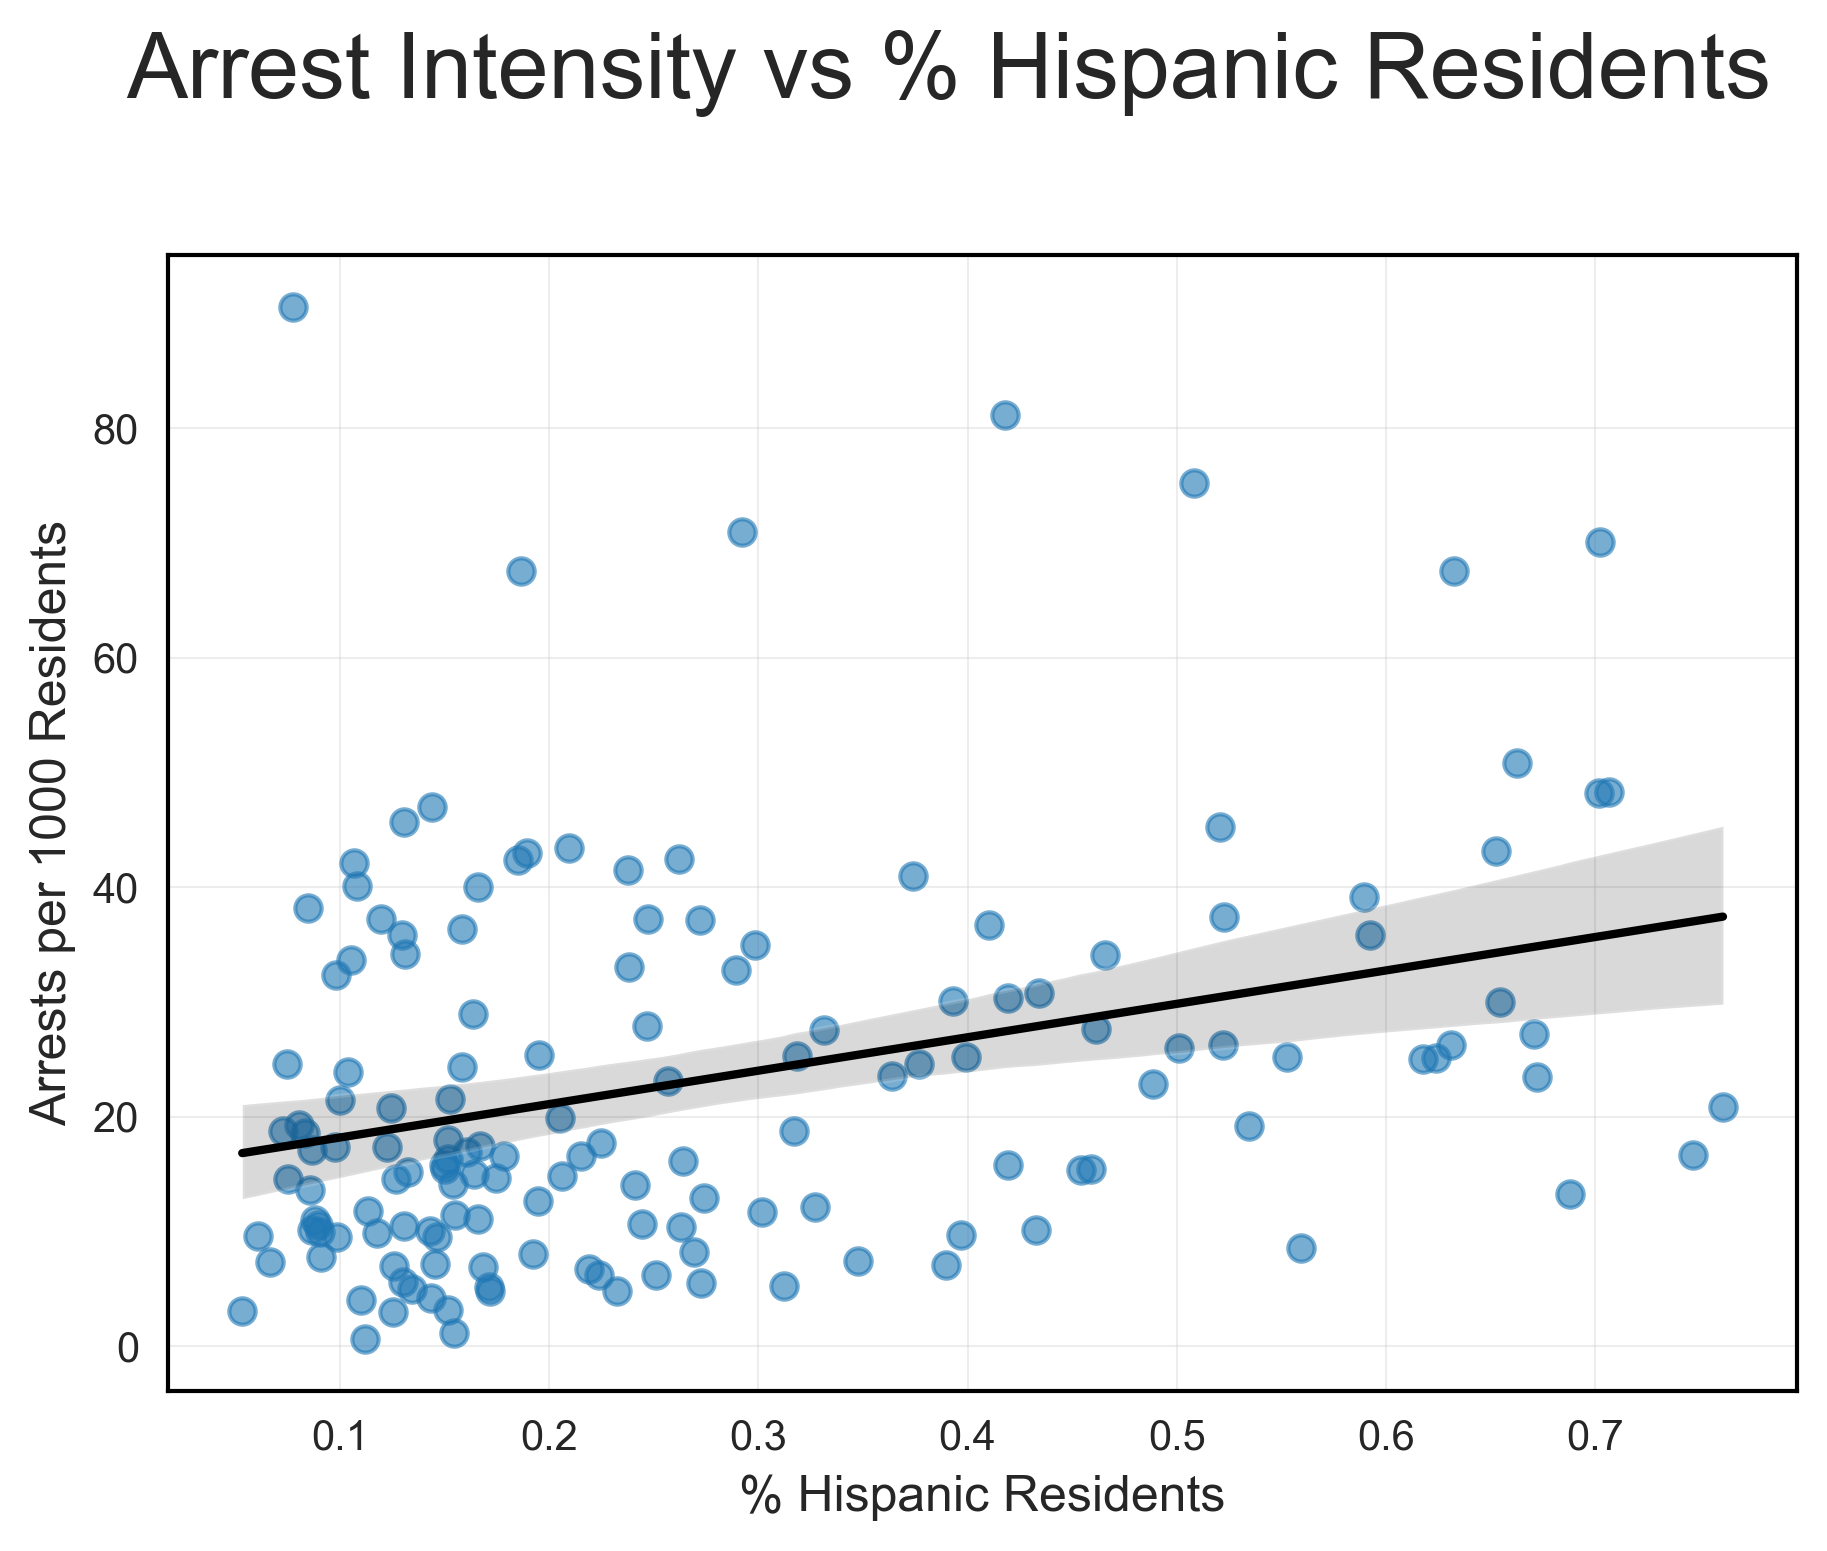

In [134]:
fig2 = regplot_clean(
    df, "pct_hispanic", "arrest_rate_per_1000",
    "% Hispanic Residents", "Arrests per 1000 Residents",
    "Arrest Intensity vs % Hispanic Residents"
)

fig2.savefig("../outputs/arrest_vs_pct_hispanic.png", dpi=300, bbox_inches="tight")

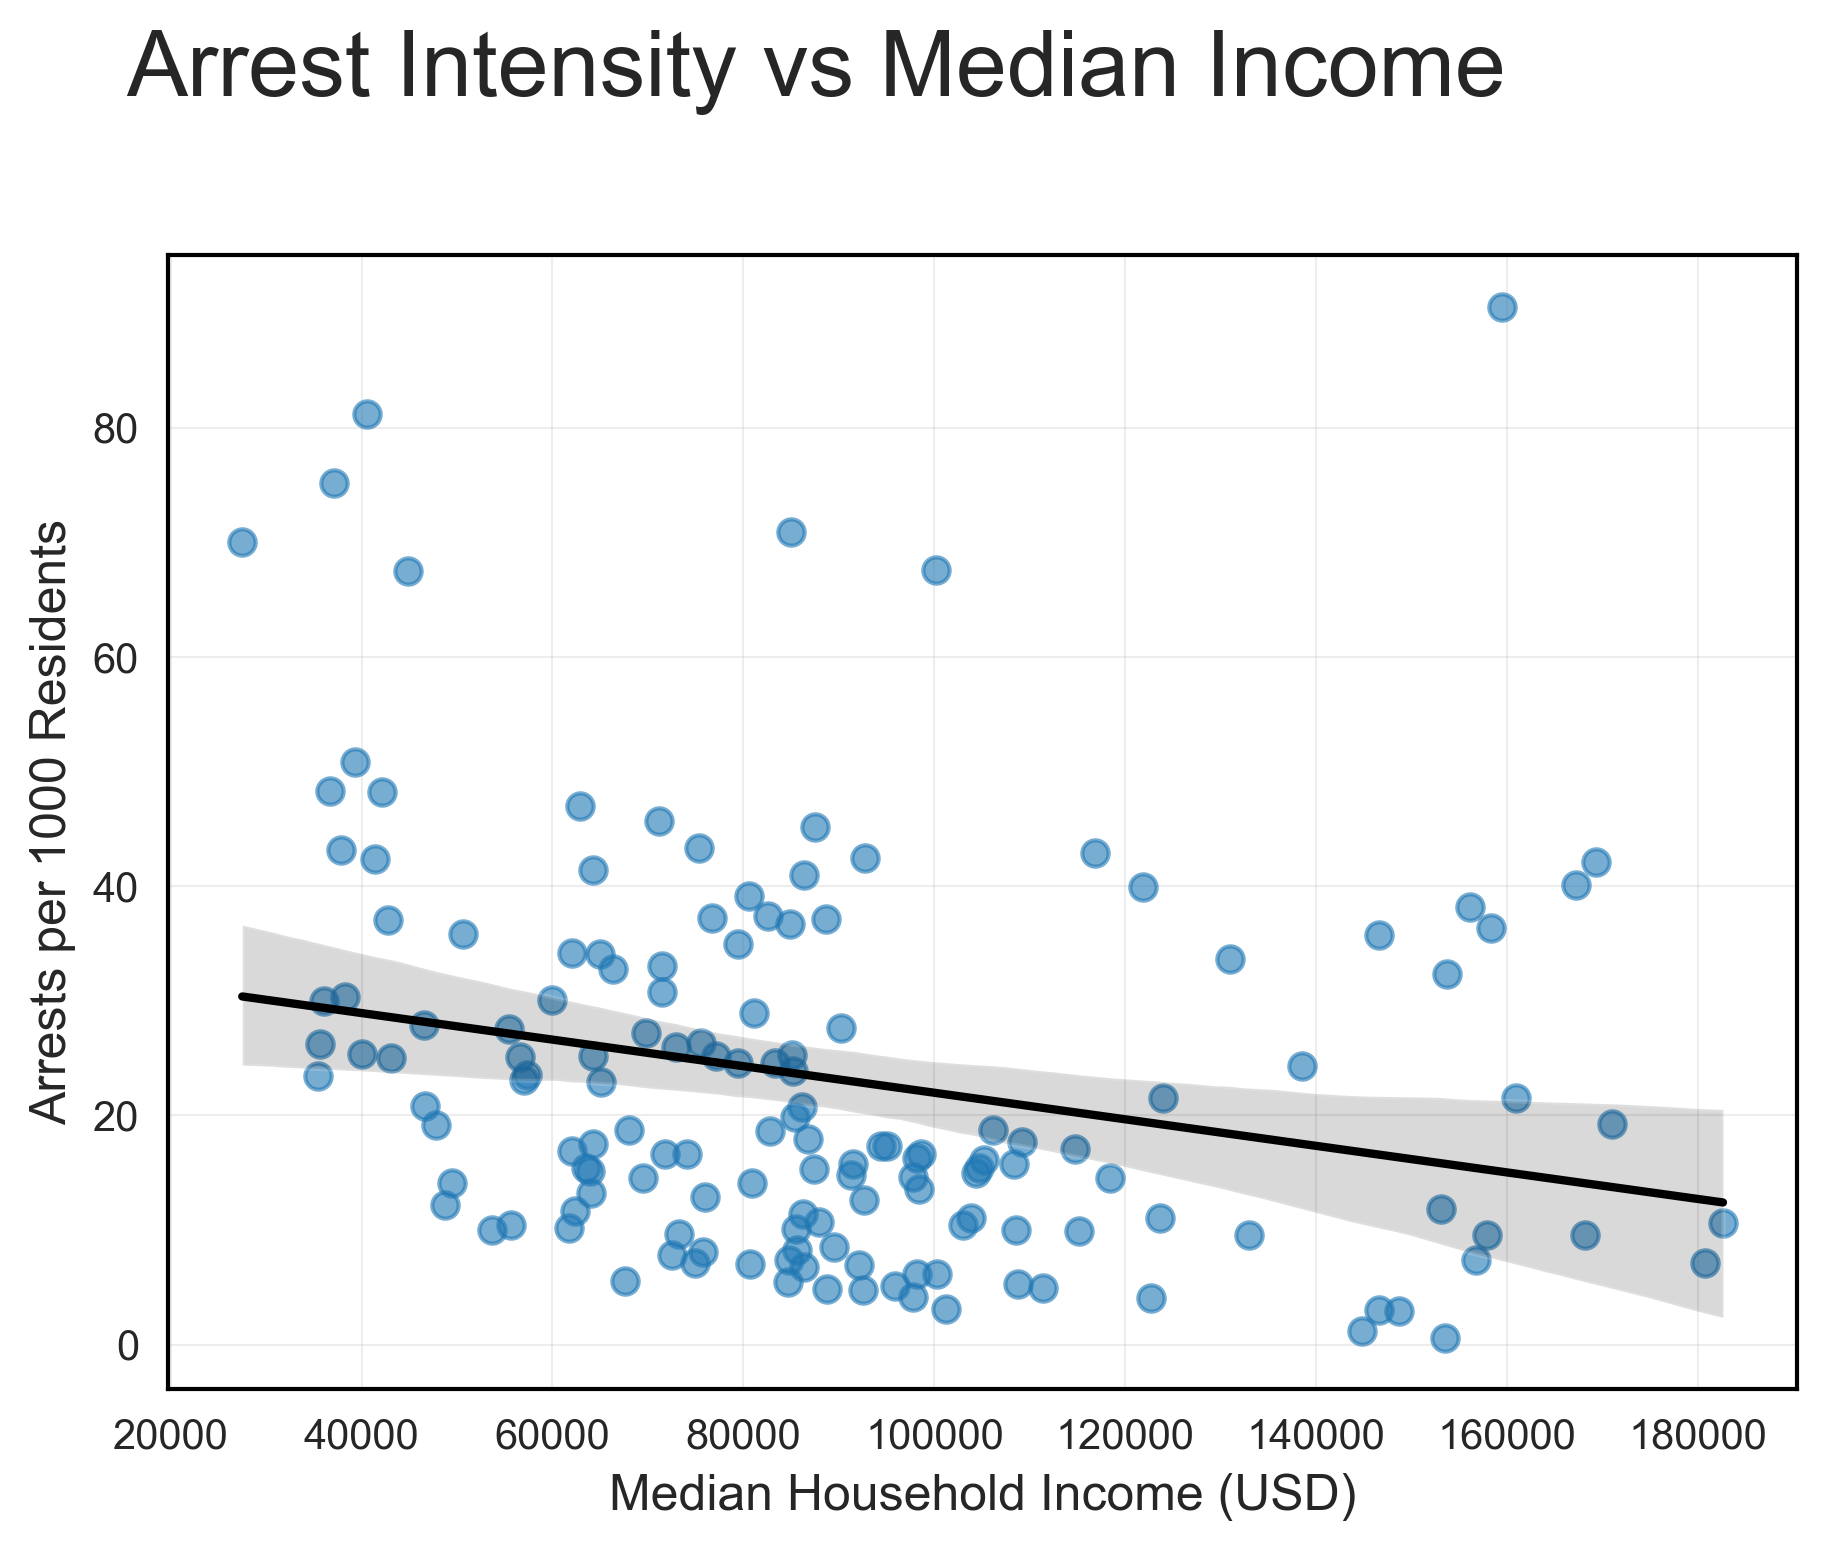

In [135]:
fig3 = regplot_clean(
    df, "median_income", "arrest_rate_per_1000",
    "Median Household Income (USD)", "Arrests per 1000 Residents",
    "Arrest Intensity vs Median Income"
)

fig3.savefig("../outputs/arrest_vs_income.png", dpi=300, bbox_inches="tight")

### 3. Descriptive Grounding (What does NYC look like in this data?)

#### 3.1 Purpose & Framing

To test whether neighborhood demographics and socioeconomic context predict arrest intensity after controlling for other characteristics, we estimate a series of regression models. These models help isolate associations between racial composition, income, and policing exposure, net of population size and offense mix.

#### 3.2 Prepare Data for Regression

In [136]:
reg = df.copy()

# reg["median_income"] = reg["median_income"] / 10000  # scale to tens of thousands

for col in ["felonies", "misdemeanors", "violations"]:
    if col in reg.columns:
        reg[col] = reg[col] / reg["total_arrests"]

reg["log_pop"] = np.log(reg["total_pop"])

y = reg["arrest_rate_per_1000"]

X1 = reg[["pct_black", "pct_hispanic"]]  # Race-only model
X2 = reg[["pct_black", "pct_hispanic", "median_income", "below_poverty"]]  # Add SES
X3 = reg[["pct_black", "pct_hispanic", "median_income", "below_poverty", "log_pop"]]  # Add size control

#### 3.3 Run OLS Models

In [137]:
def run_ols(X, y):
    Xc = sm.add_constant(X)
    model = sm.OLS(y, Xc).fit()
    return model

m1 = run_ols(X1, y)
m2 = run_ols(X2, y)
m3 = run_ols(X3, y)

print(m1.summary())
print(m2.summary())
print(m3.summary())

                             OLS Regression Results                             
Dep. Variable:     arrest_rate_per_1000   R-squared:                       0.135
Model:                              OLS   Adj. R-squared:                  0.124
Method:                   Least Squares   F-statistic:                     11.59
Date:                  Wed, 03 Dec 2025   Prob (F-statistic):           2.11e-05
Time:                          22:17:41   Log-Likelihood:                -629.36
No. Observations:                   151   AIC:                             1265.
Df Residuals:                       148   BIC:                             1274.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.3887     

A thorough interpretation:

- Model 1 (Race only)  
  - Percent Black (β = 13.17, p = 0.024) and percent Hispanic (β = 30.05, p < 0.001) are both positively associated with arrest intensity.  
  - Racial composition alone explains about 13 percent of the variance in arrest rates across ZIP codes (R² = 0.135).  
  - ZIP codes with larger Hispanic and Black populations tend to have higher arrest rates.

- Model 2 (Adding socioeconomic variables)  
  - Adding median income and poverty does little to change the overall model fit (R² = 0.141).  
  - Race coefficients remain positive and significant, indicating that racial composition predicts arrest intensity even after accounting for income and poverty.  
  - Median income and poverty rate are not significant, likely because of strong collinearity with race.

- Model 3 (Full model with population control)  
  - The model fit improves modestly (R² = 0.176).  
  - Percent Hispanic remains a strong positive predictor (β = 26.34, p = 0.005), while percent Black becomes marginally significant (β = 12.06, p = 0.064).  
  - Poverty rate is now significant (β = 0.0009, p = 0.014), suggesting higher arrest rates in poorer areas.  
  - The log of population is negatively associated with arrest intensity (β = –11.53, p = 0.015), confirming that smaller ZIP codes show higher arrest rates per capita.

- Overall interpretation  
  - Across all specifications, ZIP codes with larger Hispanic populations consistently experience higher arrest intensity.  
  - Economic disadvantage and smaller population size also contribute to greater policing exposure.  
  - The persistence of these effects after controlling for socioeconomic and size factors supports the view that arrest disparities are structural and not simply artifacts of demographic or geographic variation.

#### 3.3 Generalized Linear Model Application - Poisson

Why Poisson?

- The outcome (total_arrests) is a non-negative integer count.
- ZIPs have different populations (exposure), so we include an offset (log(total_pop)).
- The model estimates the expected number of arrests per population unit, adjusting for predictors like race, income, and poverty.

In [138]:
reg = df.copy()

reg["log_pop"] = np.log(reg["total_pop"])

X_pois = reg[["pct_black", "pct_hispanic", "median_income", "below_poverty"]]
X_pois = sm.add_constant(X_pois)

y_counts = reg["total_arrests"]

poisson_model = sm.GLM(
    y_counts,
    X_pois,
    family=sm.families.Poisson(),
    offset=reg["log_pop"]
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          total_arrests   No. Observations:                  151
Model:                            GLM   Df Residuals:                      146
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31505.
Date:                Wed, 03 Dec 2025   Deviance:                       61710.
Time:                        22:17:41   Pearson chi2:                 7.31e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.2655      0.016   -261.624

The Poisson model uses total arrests as a count outcome and includes population size as an exposure term, allowing interpretation of coefficients as changes in the expected arrest rate.

- Percent Black and percent Hispanic are both strong positive predictors of arrest intensity.
  - The coefficient for percent Black ($\beta$ = 0.71, p < 0.001) implies that, holding other factors constant, a 10 percentage-point increase in Black population share corresponds to roughly a 7 percent higher expected arrest rate.
  - The coefficient for percent Hispanic ($\beta$ = 1.18, p < 0.001) implies that a 10 percentage-point increase in Hispanic population share corresponds to about a 12 percent higher arrest rate.

- Median income has a small, marginally negative effect (p ≈ 0.06), while the poverty variable becomes negative and barely significant (p = 0.049). These shifts likely reflect multicollinearity among race and class indicators.

- The direction and significance of the racial composition variables are consistent with the OLS models, confirming that racial and socioeconomic disparities persist when arrests are modeled as count data normalized by population.

- The model shows signs of overdispersion (deviance and Pearson chi-squared much larger than degrees of freedom), suggesting that standard errors may be slightly understated. A Negative Binomial specification would provide a robustness check.

- Overall, the Poisson model reinforces the core finding that arrest exposure is disproportionately concentrated in neighborhoods with higher proportions of Black and Hispanic residents, even after controlling for population size and economic context.

## 3.4 Clustering 

This is an additional clustering analysis to identify areas that exhibit similar arrest rate sod demographics. 

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_vars = df[[
    "arrest_rate_per_1000",
    "pct_black", "pct_hispanic", "pct_white",
    "median_income", "below_poverty"
]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_vars)

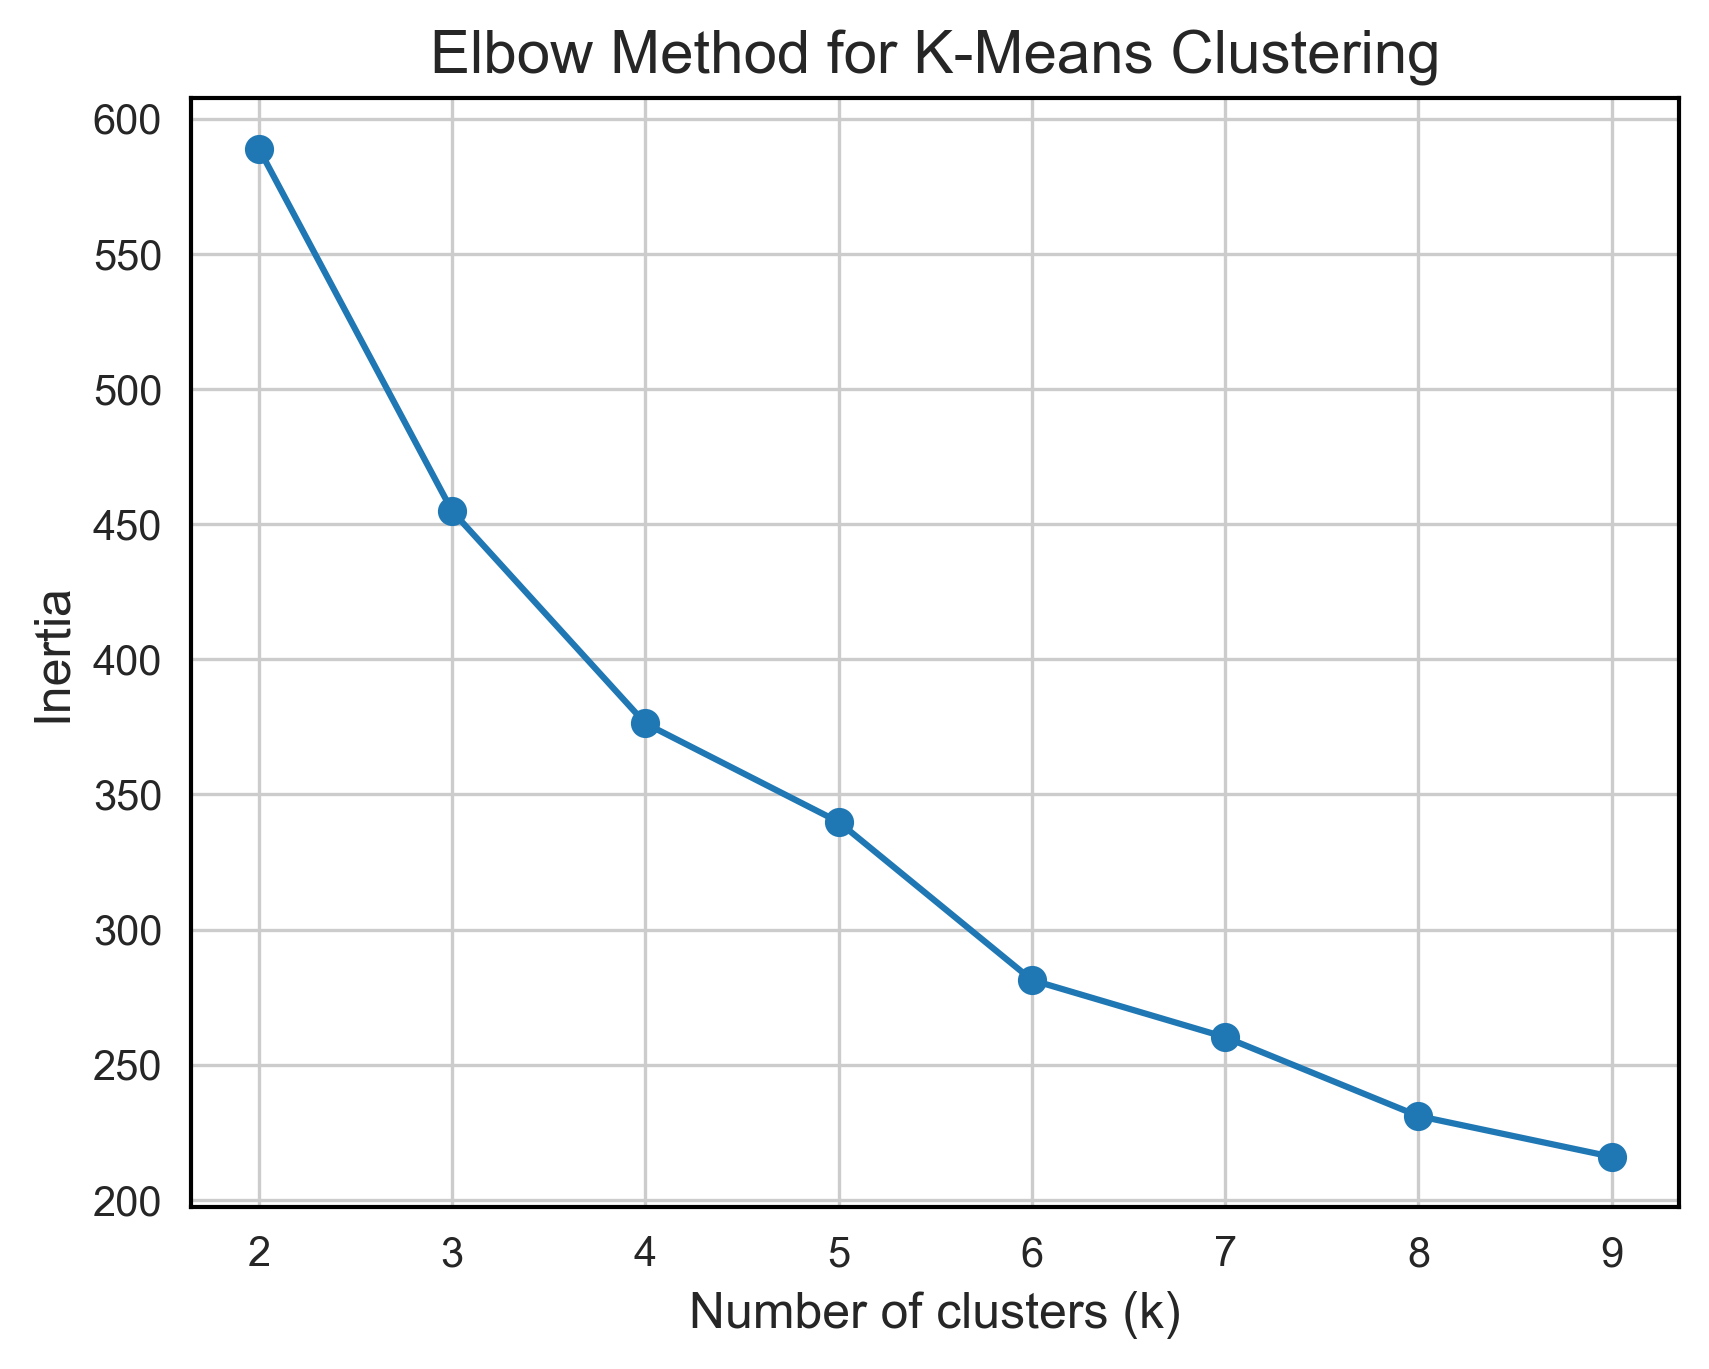

In [140]:
inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

In [141]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: "Black-Majority / Moderate Arrest",
    1: "White-Mixed / Low Arrest",
    2: "Hispanic-Majority / High Arrest",
    3: "White-Affluent / Low Arrest"
}

df.groupby("cluster")[[
    "arrest_rate_per_1000",
    "pct_black", "pct_hispanic", "pct_white",
    "median_income", "below_poverty"
]].mean().round(2)

,arrest_rate_per_1000,pct_black,pct_hispanic,pct_white,median_income,below_poverty
cluster,,,,,,
0,21.43,0.59,0.17,0.11,77266.57,8888.25
1,13.24,0.07,0.23,0.43,89686.71,7330.06
2,36.30,0.20,0.50,0.14,58893.57,15435.80
3,23.23,0.04,0.11,0.66,148466.85,3514.74


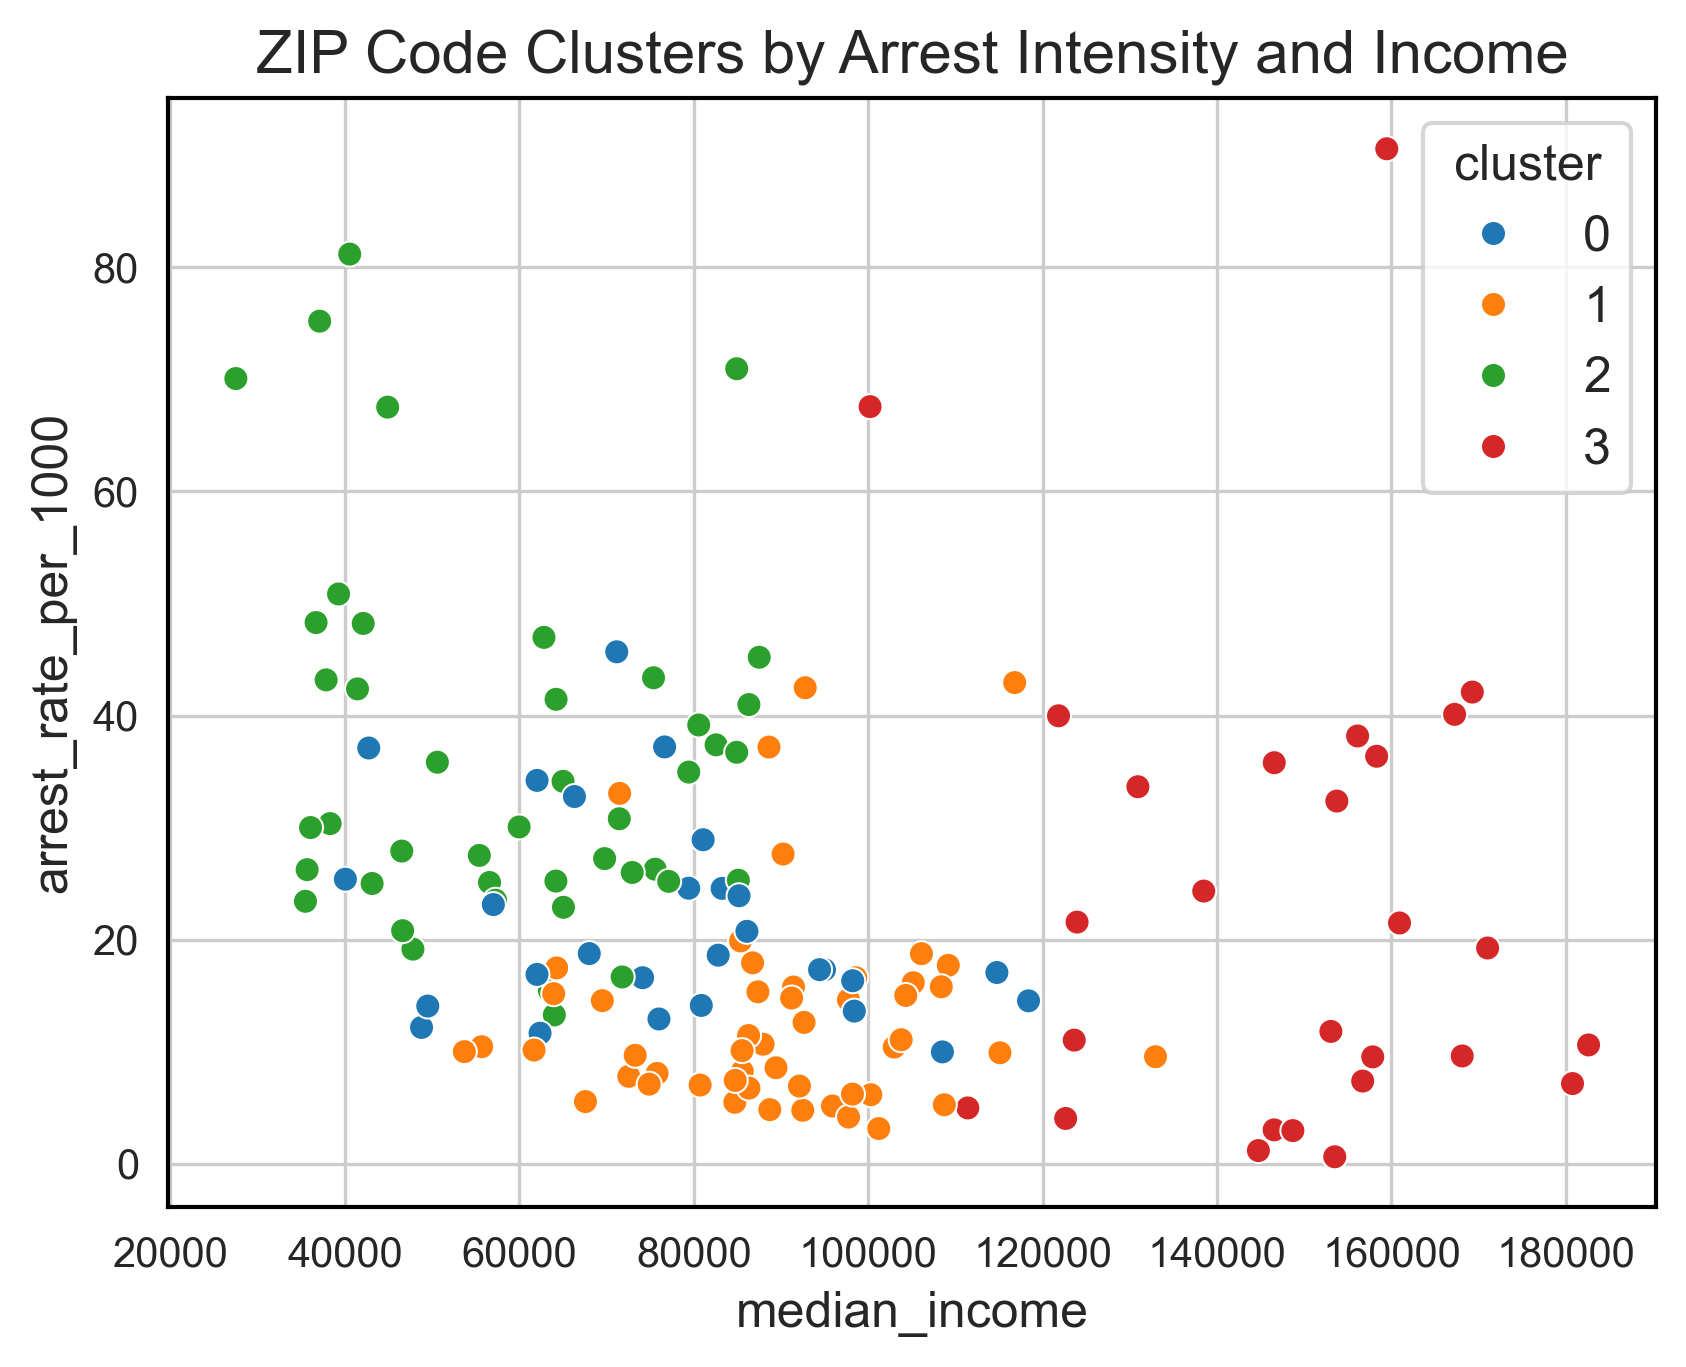

In [142]:
sns.scatterplot(
    data=df,
    x="median_income",
    y="arrest_rate_per_1000",
    hue="cluster",
    palette="tab10"
)
plt.title("ZIP Code Clusters by Arrest Intensity and Income")
plt.show()

In [143]:
import geopandas as gpd

zip_geo_path = "../data/geo/nyc-zip-code-tabulation-areas.geojson"

gdf_zip = gpd.read_file(zip_geo_path)
gdf_zip.head(), gdf_zip.columns

(   OBJECTID postalCode          PO_NAME STATE borough ST_FIPS CTY_FIPS  \
 0         1      11372  Jackson Heights    NY  Queens      36      081   
 1         2      11004        Glen Oaks    NY  Queens      36      081   
 2         3      11040    New Hyde Park    NY  Queens      36      081   
 3         4      11426        Bellerose    NY  Queens      36      081   
 4         5      11365    Fresh Meadows    NY  Queens      36      081   
 
    BLDGpostalCode    Shape_Leng    Shape_Area  \
 0               0  20624.692317  2.016328e+07   
 1               0  23002.816039  2.260653e+07   
 2               0  15749.161511  6.269333e+06   
 3               0  35932.810639  4.941836e+07   
 4               0  38693.565676  6.938587e+07   
 
                                                  @id  \
 0  http://nyc.pediacities.com/Resource/PostalCode...   
 1  http://nyc.pediacities.com/Resource/PostalCode...   
 2  http://nyc.pediacities.com/Resource/PostalCode...   
 3  http://nyc.ped

In [144]:
gdf_zip["ZCTA"] = gdf_zip["postalCode"].astype(str).str.zfill(5)

df_clusters = df.copy()
df_clusters["ZCTA"] = df_clusters["ZCTA"].astype(str).str.zfill(5)

# Merge spatial polygons with cluster assignments
gdf_clusters = gdf_zip.merge(
    df_clusters[["ZCTA", "cluster", "arrest_rate_per_1000",
                 "pct_black", "pct_hispanic", "pct_white",
                 "median_income", "below_poverty"]],
    on="ZCTA",
    how="inner"
)
gdf_clusters["cluster_label"] = gdf_clusters["cluster"].map(cluster_names)

print(gdf_clusters.shape)
gdf_clusters.head()

(155, 21)


,OBJECTID,postalCode,PO_NAME,STATE,borough,ST_FIPS,CTY_FIPS,BLDGpostalCode,Shape_Leng,Shape_Area,...,geometry,ZCTA,cluster,arrest_rate_per_1000,pct_black,pct_hispanic,pct_white,median_income,below_poverty,cluster_label
0,1,11372,Jackson Heights,NY,Queens,36,081,0,20624.692317,2.016328e+07,...,"POLYGON ((-73.86942 40.74916, -73.89507 40.746...",11372,2,25.195910,0.012598,0.552623,0.181476,77133.0,9920.0,Hispanic-Majority / High Arrest
1,3,11040,New Hyde Park,NY,Queens,36,081,0,15749.161511,6.269333e+06,...,"POLYGON ((-73.70098 40.7389, -73.70309 40.7445...",11040,3,0.614019,0.011761,0.111940,0.385509,153511.0,1482.0,White-Affluent / Low Arrest
2,5,11365,Fresh Meadows,NY,Queens,36,081,0,38693.565676,6.938587e+07,...,"POLYGON ((-73.81089 40.72717, -73.81116 40.728...",11365,1,19.880716,0.108350,0.205234,0.225230,85375.0,4096.0,White-Mixed / Low Arrest
3,6,11373,Elmhurst,NY,Queens,36,081,0,33755.870988,4.265940e+07,...,"POLYGON ((-73.88722 40.72753, -73.88723 40.728...",11373,2,30.784548,0.015156,0.433991,0.048817,71470.0,11575.0,Hispanic-Majority / High Arrest
4,7,11001,Floral Park,NY,Queens,36,081,0,13594.924549,9.155180e+06,...,"POLYGON ((-73.70098 40.7389, -73.6996 40.73959...",11001,3,1.166680,0.055145,0.154507,0.512561,144755.0,948.0,White-Affluent / Low Arrest


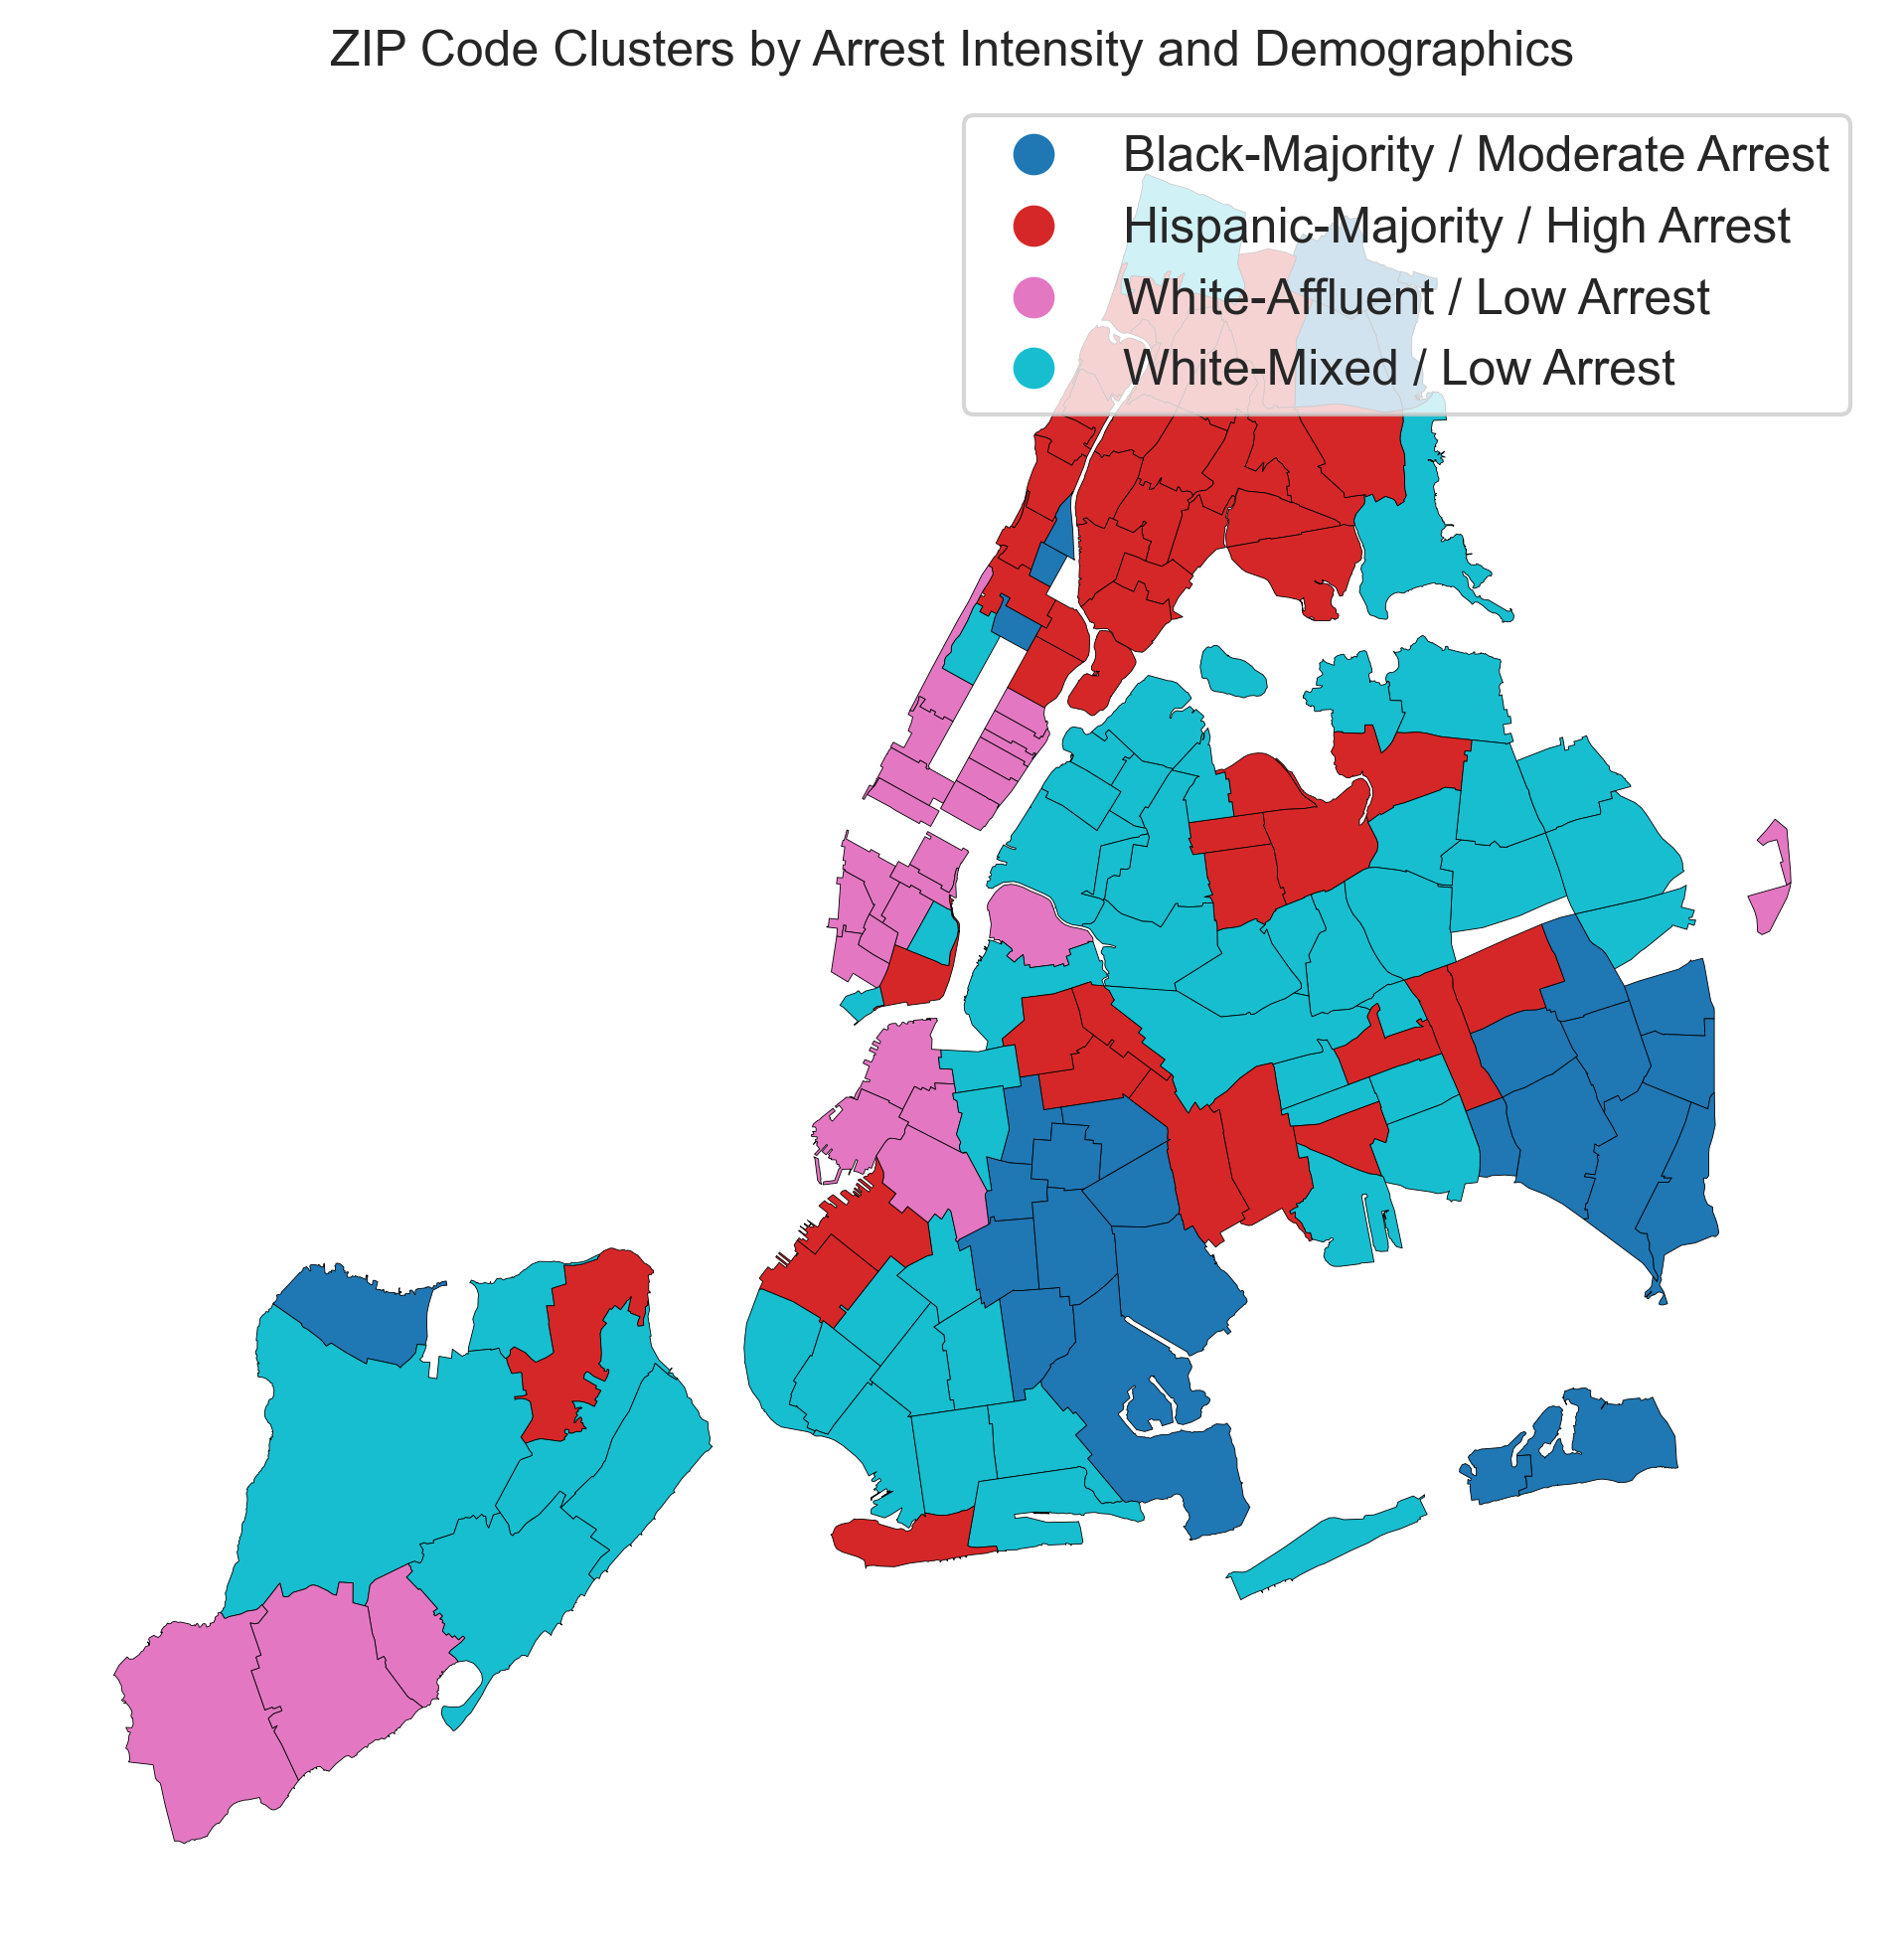

In [145]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

gdf_clusters.plot(
    column="cluster_label",
    categorical=True,
    legend=True,
    cmap="tab10",
    linewidth=0.2,
    edgecolor="black",
    ax=ax
)

ax.set_axis_off()
ax.set_title("ZIP Code Clusters by Arrest Intensity and Demographics", fontsize=12)
plt.show()

In [146]:
gdf_clusters.explore(
    column="cluster",
    cmap="tab10",
    legend=True,
    popup=["ZCTA", "cluster", "arrest_rate_per_1000",
           "pct_black", "pct_hispanic", "pct_white",
           "median_income", "below_poverty"]
)

### Clustering Analysis (k = 4): Neighborhood Profiles

Using K-means clustering on standardized variables (arrest intensity, racial composition, median income, and poverty), ZIP codes grouped naturally into four distinct clusters. These clusters represent coherent neighborhood “types” that differ in policing exposure and demographic composition.

#### Cluster 0: High-Black, Moderate-Arrest, Moderate-Income ZIP Codes
- Arrest rate: ~21.4 arrests per 1,000 residents  
- Percent Black: very high (0.59)  
- Percent Hispanic: moderate (0.17)  
- Percent White: very low (0.11)  
- Median income: moderate (~$77k)  
- Poverty: elevated (~8.9k estimated individuals)  
**Interpretation:**  
These ZIP codes are predominantly Black neighborhoods with moderately high arrest intensity. They exhibit structural socioeconomic constraints and long-standing patterns of disproportionate policing. Arrest rates are visibly elevated but not as extreme as the highest-intensity cluster.

#### Cluster 1: Lower-Arrest, Mixed-White ZIP Codes
- Arrest rate: ~13.2 per 1,000  
- Percent Black: low (0.07)  
- Percent Hispanic: moderate (0.23)  
- Percent White: substantial (0.43)  
- Median income: moderately high (~$90k)  
- Poverty: moderate  
**Interpretation:**  
These areas are racially mixed but substantially White, with relatively low arrest intensity. They represent mid-income, largely residential neighborhoods where enforcement levels are comparatively low. These serve as “baseline” ZIPs in the city in terms of policing exposure.

#### Cluster 2: High-Arrest, High-Poverty, Predominantly Hispanic ZIP Codes
- Arrest rate: ~36.3 per 1,000  
- Percent Black: moderate (0.20)  
- Percent Hispanic: high (0.50)  
- Percent White: low (0.14)  
- Median income: low (~$59k)  
- Poverty: very high (~15.4k individuals)  
**Interpretation:**  
These are some of the most disadvantaged ZIP codes in the city and have the **highest arrest intensities** of any cluster. The combination of high poverty, high Hispanic (and moderate Black) population shares, and low median income strongly aligns with historical patterns of over-policing in marginalized neighborhoods.

#### Cluster 3: Wealthy, Predominantly White, Low-Arrest ZIP Codes
- Arrest rate: ~23.2 per 1,000  
- Percent Black: very low (0.04)  
- Percent Hispanic: low (0.11)  
- Percent White: high (0.66)  
- Median income: very high (~$148k)  
- Poverty: low  
**Interpretation:**  
These represent New York’s wealthiest ZIP codes. Despite high population density in some cases, arrest intensities are relatively low. These ZIP codes exemplify neighborhoods that benefit from socioeconomic resources and low levels of police intervention. They form a strong contrast to Cluster 2.

### Summary of Clustering Patterns

- **Cluster 2** stands out as the highest-arrest and highest-poverty group, predominantly Hispanic and lower-income.  
- **Cluster 3** consists of wealthy, majority-White ZIP codes with low arrest intensity.  
- **Cluster 0** is majority Black with moderate arrest intensity and moderate socioeconomic disadvantage.  
- **Cluster 1** is mixed but White-leaning, with low arrest rates and mid-to-high incomes.

These clusters reveal that arrest intensity is strongly structured by racial composition and socioeconomic conditions. The differences between clusters mirror broader patterns in New York City’s racialized geography of policing. This provides a structural context for the fairness analysis that follows, where we quantify the extent to which racial disparities in policing persist within and across these neighborhood types.

## 4. Fairness Analysis

Having established statistical associations between neighborhood demographics and arrest intensity, we next examine the fairness dimension of policing outcomes. The goal is to determine whether racial or ethnic groups experience systematically different arrest rates, both across the city as a whole and within local areas. These analyses translate the regression results into interpretable fairness metrics that capture relative exposure to enforcement.

#### 4.1 Fairness Ratios

In [147]:
totals = {
    "black_arrests": df.get("BLACK", pd.Series(0)).sum(),
    "white_arrests": df.get("WHITE", pd.Series(0)).sum(),
    "hispanic_arrests": (df.get("WHITE HISPANIC", 0) + df.get("BLACK HISPANIC", 0)).sum(),
    "asian_arrests": df.get("ASIAN / PACIFIC ISLANDER", pd.Series(0)).sum(),
    "native_arrests": df.get("AMERICAN INDIAN/ALASKAN NATIVE", pd.Series(0)).sum(),
    "black_pop": df["black_count"].sum(),
    "white_pop": df["white_count"].sum(),
    "hispanic_pop": df["hispanic_count"].sum(),
    "asian_pop": df["asian_count"].sum(),
    "native_pop": df["native_count"].sum()
}

def rate(count, pop):
    return (count / pop) * 1000 if pop > 0 else np.nan

city_rates = {
    "black_arrest_rate": rate(totals["black_arrests"], totals["black_pop"]),
    "white_arrest_rate": rate(totals["white_arrests"], totals["white_pop"]),
    "hispanic_arrest_rate": rate(totals["hispanic_arrests"], totals["hispanic_pop"]),
    "asian_arrest_rate": rate(totals["asian_arrests"], totals["asian_pop"]),
    "native_arrest_rate": rate(totals["native_arrests"], totals["native_pop"])
}

city_rates

{'black_arrest_rate': np.float64(50.87605677161535),
 'white_arrest_rate': np.float64(7.379044718970703),
 'hispanic_arrest_rate': np.float64(29.441025845625717),
 'asian_arrest_rate': np.float64(9.25201825975881),
 'native_arrest_rate': np.float64(39.431074988888184)}

In [148]:
bw_ratio = city_rates["black_arrest_rate"] / city_rates["white_arrest_rate"]
hw_ratio = city_rates["hispanic_arrest_rate"] / city_rates["white_arrest_rate"]
aw_ratio = city_rates["asian_arrest_rate"] / city_rates["white_arrest_rate"]

print(f"Black-to-White arrest rate ratio: {bw_ratio:.2f}")
print(f"Hispanic-to-White arrest rate ratio: {hw_ratio:.2f}")
print(f"Asian-to-White arrest rate ratio: {aw_ratio:.2f}")

Black-to-White arrest rate ratio: 6.89
Hispanic-to-White arrest rate ratio: 3.99
Asian-to-White arrest rate ratio: 1.25


#### 4.2 ZIP-level Fairness and Summary Statistics

In [149]:
df_fair = df.copy()

# Compute group-specific arrest rates per 1,000 residents
for race, pop_col, arrest_col in [
    ("BLACK", "black_count", "BLACK"),
    ("WHITE", "white_count", "WHITE"),
    ("HISPANIC", "hispanic_count", "HISPANIC_ARRESTS")
]:
    if pop_col in df_fair.columns and arrest_col in df_fair.columns:
        df_fair[f"{race.lower()}_rate_per_1000"] = (
            df_fair[arrest_col] / df_fair[pop_col].replace({0: np.nan})
        ) * 1000


df_fair["bw_ratio_zip"] = df_fair["black_rate_per_1000"] / df_fair["white_rate_per_1000"]
df_fair["hw_ratio_zip"] = df_fair["hispanic_rate_per_1000"] / df_fair["white_rate_per_1000"]

df_fair[["ZCTA", "bw_ratio_zip", "hw_ratio_zip"]].head()

,ZCTA,bw_ratio_zip,hw_ratio_zip
2,10002,13.148829,3.925896
3,10003,45.338303,13.762211
8,10009,16.747270,5.090705
9,10010,21.279770,11.834966
10,10011,43.310321,10.114426


In [150]:
bw_summary = df_fair["bw_ratio_zip"].describe()
hw_summary = df_fair["hw_ratio_zip"].describe()

bw_summary, hw_summary

(count    151.000000
 mean      19.331080
 std       30.040871
 min        0.418372
 25%        3.578693
 50%        9.552022
 75%       19.908814
 max      203.372845
 Name: bw_ratio_zip, dtype: float64,
 count    151.000000
 mean       4.961011
 std        5.392008
 min        0.448201
 25%        1.773185
 50%        3.043665
 75%        6.216272
 max       36.491316
 Name: hw_ratio_zip, dtype: float64)


Citywide Disparities

- The overall Black-to-White arrest rate ratio is 6.9, indicating that, per capita, Black residents are arrested nearly seven times more often than White residents.
- The Hispanic-to-White ratio is 4.0, showing that Hispanic residents experience roughly four times the arrest rate of White residents.
- The Asian-to-White ratio is 1.25, suggesting a relatively similar or slightly higher exposure compared to White residents.

These citywide results confirm that arrest exposure is not evenly distributed across racial groups. Even when accounting for population size, Black and Hispanic residents face substantially higher policing intensity.

ZIP-Level Patterns

- Across 151 ZIP codes, the average Black-to-White arrest intensity ratio is 19.3, with a median of 9.6 and values ranging up to 203 in some areas.
- The average Hispanic-to-White ratio is 5.0, with a median of 3.0 and values reaching 36 in certain neighborhoods.
- In almost all ZIPs, both ratios exceed 1, meaning Black and Hispanic residents are arrested at higher rates than White residents within the same geographic area.
- The magnitude and variability of these ratios show that racial disparities are spatially concentrated but systemic—many ZIPs, particularly in lower Manhattan, Harlem, the Bronx, and parts of Brooklyn, exhibit extreme inequality in arrest intensity.

Interpretation

- These disparities represent more than random variation. The consistent elevation of Black and Hispanic arrest rates across neighborhoods indicates a structural pattern in which enforcement is disproportionately concentrated in communities of color.
- The exceptionally high local ratios (often exceeding 10:1 for Black-to-White) suggest that even within demographically mixed ZIP codes, Black residents face a much greater likelihood of arrest per capita.
- These findings align with prior research on racialized policing in New York City and underscore the ethical risks of using arrest data as a neutral input for predictive or data-driven policing models. When such data reflect existing bias, they risk perpetuating and legitimizing structural inequities.

Ethical Implications

- From a data ethics standpoint, transparency in data provenance, model auditing, and explicit bias mitigation are essential before integrating such arrest data into any decision-making or predictive system.